# Simulating Grover's Search Algorithm in Comparison to Classical Linear Search

### An Interactive Pedagogy for Quantum Information Systems

**Alexander Bousman**  
Written April 18, 2025, Revised September 16, 2026

Suppose you have an unsorted collection and know only how to ask, “Is this the item I want?” Classical linear search may have to inspect every candidate. Grover's algorithm uses quantum interference to reduce the number of calls to that yes-or-no test from order $N$ to order $\sqrt{N}$.

By the end, you should be able to explain:

1. Why amplitudes are different from probabilities
2. What the oracle and diffusion operator each accomplish
3. Why the two operations together amplify a marked state
4. Why Grover's algorithm must be stopped near a particular iteration
5. What the $O(\sqrt N)$ claim does, and does not, mean

The examples adapt `linearSearch.py`, `quantumRandomWalk.py`, `groverSearch.py`, `lookup.py`, `iterations.py`, and `groverPIN.py` from the "Grover Applications" and "Grover Visualization" folders. We use NumPy statevectors so the internal amplitudes remain visible. Note: these are classical simulations of ideal quantum systems, they don't fully represent legitimate quantum hardware.

## How to Use This Notebook

Run the cells in order. When a cell says **Try It**, change the indicated parameter and rerun that cell and the cells immediately below it. Short **Stop and Think** questions invite you to reason before viewing the result.

The Grover's algorithm methodology will involve a little prerequisite familiarity with linear algebra and bra-ket notation. Only NumPy and Matplotlib are required for the main lesson. The quantum-walk section also uses SciPy. If necessary, uncomment and run the installation line below once.

In [15]:
# %pip install numpy matplotlib scipy

import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 3.8),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#4c78a8"
RED = "#e45756"
GREEN = "#54a24b"
GOLD = "#f2cf5b"

def bit_label(index, n):
    return format(index, f"0{n}b")

def plot_bars(values, n, title, ylabel="Probability", marked=(), mean_line=False):
    '''Plot one value per computational-basis state.'''
    x = np.arange(len(values))
    colors = [RED if i in marked else BLUE for i in x]
    fig, ax = plt.subplots()
    ax.bar(x, values, color=colors)
    if len(x) <= 32:
        ax.set_xticks(x, [bit_label(i, n) for i in x], rotation=60)
    if mean_line:
        ax.axhline(np.mean(values), color="black", linestyle="--", label="Mean amplitude")
        ax.legend()
    ax.set(xlabel="Computational-basis state", ylabel=ylabel, title=title)
    plt.tight_layout()
    plt.show()

## Roadmap

The notebook will progress as such:

1. **Introduction:** Formulate unstructured search and establish a classical baseline.
2. **Quantum Information:** Build the vocabulary of states, amplitudes, measurement, and superposition.
3. **Quantum Random Walk:** Visualize interference in a related quantum process.
4. **Overview of Grover's Algorithm:** Study initialization, the oracle, and diffusion separately.
5. **Grover's Circle and Time Complexity:** Derive the rotation picture and iteration count.
6. **Simulation and Comparison:** Run complete searches, sample measurements, and compare query scaling.
7. **Applications:** Identify problems that can genuinely be written as oracle search.
8. **Limitations:** Separate the theoretical query advantage from practical computing costs.
9. **Conclusion:** Consolidate the full mechanism in plain language.

# 1. Introduction: The Problem of Unstructured Search

Imagine you're a really bad magician with a deck of cards. Your volunteer has picked a card, but you can't remember where you put it in the deck. The deck cards have no useful ordering, and your amnesia has left you without a magic trick to remember. How would you go about finding the card?

Computationally speaking, the most you could do is fan through the deck and verify if the current card matches what you're looking for. You, the classical algorithm, have no clue which to inspect first.

Let the candidate indices be $0,1,\ldots,N-1$, and define a verifier

$$
f(x)=\begin{cases}
1,&x\text{ is a solution},\\
0,&x\text{ is not a solution}.
\end{cases}
$$

This is what's called an **unstructured search** problem, as the algorithm queries $f$ on candidate indices.

### 1.1 Classical Linear Search

**Stop and Think:** For the list below, how many comparisons will be made when the target is 7? What about 4? What if the target is absent?

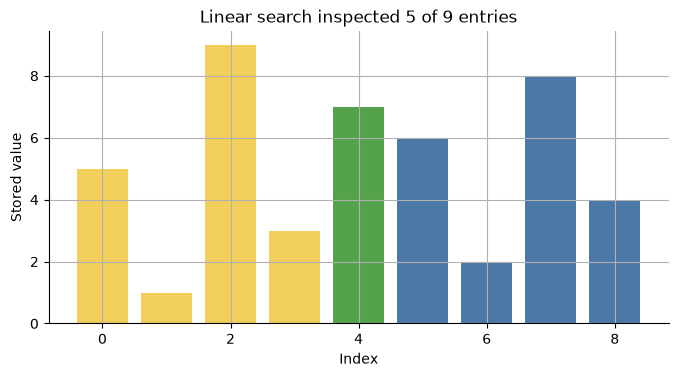

Inspected indices: [0, 1, 2, 3, 4]
Result: 4


In [16]:
def linear_search(data, target):
    '''Return the first matching index and the indices inspected.'''
    checked = []
    for index, value in enumerate(data):
        checked.append(index)
        if value == target:
            return index, checked
    return -1, checked

data = [5, 1, 9, 3, 7, 6, 2, 8, 4]
target = 7                       # Try 4 or 10
found_index, checked = linear_search(data, target)

colors = [GOLD if i in checked else BLUE for i in range(len(data))]
if found_index >= 0:
    colors[found_index] = GREEN

fig, ax = plt.subplots()
ax.bar(range(len(data)), data, color=colors)
ax.set(xlabel="Index", ylabel="Stored value",
       title=f"Linear search inspected {len(checked)} of {len(data)} entries")
plt.show()
print("Inspected indices:", checked)
print("Result:", found_index)

With one target placed uniformly at random, linear search uses $(N+1)/2$ verifier calls on average. Its worst case uses $N$ calls. Both grow as $\Theta(N)$.

This inefficiency is what Grover's Algorithm addresses. Rather than looking at every item one-by-one return a list of all values, Grover's algorithm will be able to make judgements about every item in its search setting simultaneously. 

# 2. Quantum Information

Before building Grover's algorithm, we need to distinguish three ideas that are easy to blur together:

- A **basis state**, such as $|0\rangle$ or $|101\rangle$
- A **probability amplitude**, which may be negative or complex
- A **measurement probability**, the squared magnitude of an amplitude

This distinction will be crucial to understanding quantum information processing and the algorithm later on.

### 2.1 One Qubit

A classical bit is either 0 or 1. A pure qubit state is a normalized vector

$$|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
\qquad |\alpha|^2+|\beta|^2=1.$$

If we measure in the computational basis, the outcome is 0 with probability $|\alpha|^2$ and 1 with probability $|\beta|^2$. Measurement will collapse the qubit state into one classical bit. It does not reveal both amplitudes, as this sort of [measurement problem](https://en.wikipedia.org/wiki/Measurement_problem) is central to quantum mechanics.

The next cell simulates repeated measurements. **Try It:** Change `alpha` and `beta`, but preserve normalization.

State amplitudes: [0.70710678+0.j         0.        +0.70710678j]
Exact probabilities: [0.5 0.5]
Observed frequencies: [0.503 0.497]


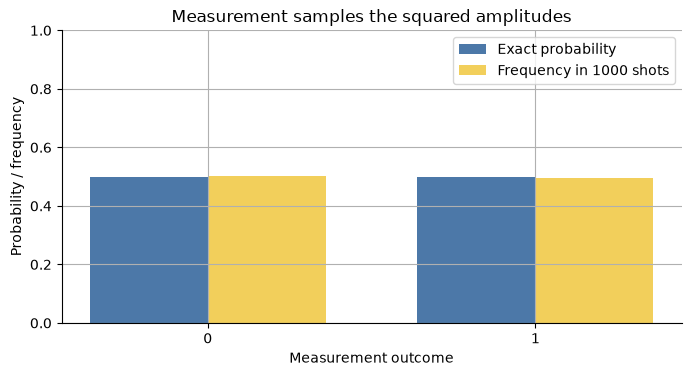

In [17]:
alpha = 1 / np.sqrt(2)
beta = 1j / np.sqrt(2)          # A complex amplitude is allowed
qubit = np.array([alpha, beta], dtype=complex)

norm = np.vdot(qubit, qubit).real
probabilities = np.abs(qubit) ** 2
assert np.isclose(norm, 1.0)

rng = np.random.default_rng(12)
shots = 1000
measurements = rng.choice([0, 1], size=shots, p=probabilities)
frequencies = np.bincount(measurements, minlength=2) / shots

print("State amplitudes:", qubit)
print("Exact probabilities:", probabilities)
print("Observed frequencies:", frequencies)

fig, ax = plt.subplots()
x = np.arange(2)
ax.bar(x - 0.18, probabilities, width=0.36, label="Exact probability", color=BLUE)
ax.bar(x + 0.18, frequencies, width=0.36, label=f"Frequency in {shots} shots", color=GOLD)
ax.set(xticks=x, xticklabels=["0", "1"], ylim=(0, 1),
       xlabel="Measurement outcome", ylabel="Probability / frequency",
       title="Measurement samples the squared amplitudes")
ax.legend()
plt.show()

### 2.2 Multiple Qubits and The Computational Basis

An $n$-qubit register has $2^n$ computational-basis states. Two qubits have $|00\rangle,|01\rangle,|10\rangle,|11\rangle$; three have eight states from $|000\rangle$ through $|111\rangle$.

The statevector therefore has $2^n$ amplitudes. This exponential dimension makes quantum states expressive, but it is **not by itself an exponential computational speedup**. Measurement still returns only one bitstring, and useful algorithms must engineer interference so a helpful answer is likely.

In [18]:
print(" Qubits | Basis States | Statevector Amplitudes")
print("--------|--------------|-----------------------")
for n_qubits in range(1, 11):
    dimension = 2 ** n_qubits
    print(f"{n_qubits:7d} | {dimension:12,d} | {dimension:21,d}")

 Qubits | Basis States | Statevector Amplitudes
--------|--------------|-----------------------
      1 |            2 |                     2
      2 |            4 |                     4
      3 |            8 |                     8
      4 |           16 |                    16
      5 |           32 |                    32
      6 |           64 |                    64
      7 |          128 |                   128
      8 |          256 |                   256
      9 |          512 |                   512
     10 |        1,024 |                 1,024


### 2.3 Hadamard Gates and Uniform Superposition

Grover's algorithm begins in $|0\cdots0\rangle$ and applies a Hadamard gate to every qubit. For one qubit,

$$H=\frac{1}{\sqrt2}\begin{bmatrix}1&1\\1&-1\end{bmatrix},
\qquad H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}.$$

For $n$ qubits, $H^{\otimes n}$ produces the uniform state

$$|s\rangle=\frac{1}{\sqrt N}\sum_{x=0}^{N-1}|x\rangle,
\qquad N=2^n.$$

Every candidate begins with amplitude $1/\sqrt N$ and probability $1/N$.

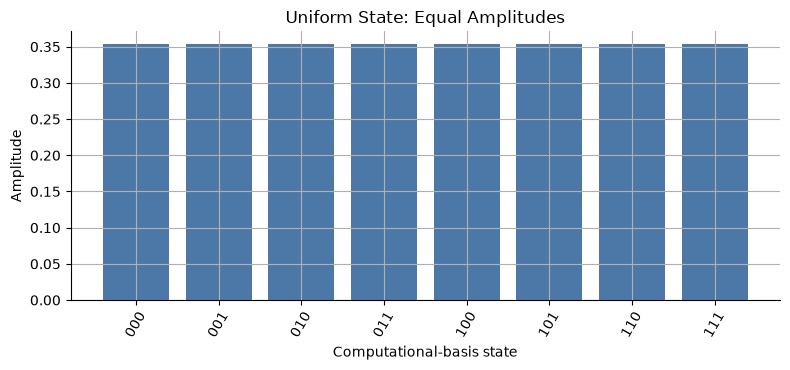

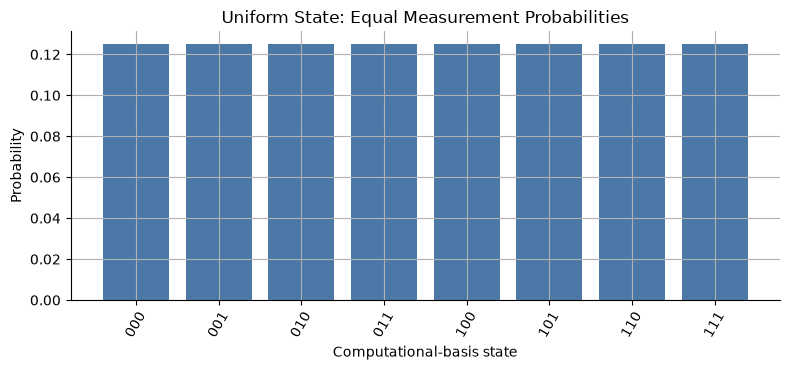

Amplitude of each state: 0.35355339059327373
Probability of each state: 0.12499999999999997
Total probability: 0.9999999999999998


In [19]:
def uniform_state(n):
    '''Return |s>, the uniform state on n qubits.'''
    if not isinstance(n, int) or n < 1:
        raise ValueError("n must be a positive integer")
    return np.ones(2**n, dtype=complex) / np.sqrt(2**n)

n = 3                          # Try 2, 3, or 4
state = uniform_state(n)

plot_bars(state.real, n, "Uniform State: Equal Amplitudes", "Amplitude")
plot_bars(np.abs(state)**2, n, "Uniform State: Equal Measurement Probabilities")
print("Amplitude of each state:", state[0].real)
print("Probability of each state:", abs(state[0])**2)
print("Total probability:", np.vdot(state, state).real)

**Checkpoint 1**

1. If an amplitude changes from $+1/2$ to $-1/2$, does its measurement probability change?
2. How many amplitudes describe 10 qubits?
3. Why is a uniform superposition not already the answer to search?

<details><summary>Check your reasoning</summary>

1. No. Both amplitudes have squared magnitude $1/4$. The sign matters only when amplitudes later interfere.
2. $2^{10}=1024$.
3. A measurement of the uniform state returns a uniformly random candidate. We still need interference to favor solutions.

</details>

# 3. Quantum Random Walk

With a foundation for quantum information established, it's now mandatory to talk about quantum random walks. Quantum random walks, the quantum analog to classical random walks, produce elegant solutions to optimization problems and form the basis for most quantum search algorithms. This is crucial for our focus on efficient search in unsorted collections, and will be biased to exploit quantum interference in search of a target state.



### 3.1 Visualizing Quantum Interference

For a continuous-time quantum random walk, there exists a Hamiltonian that connects neighboring sites. Starting from a localized state $|\psi(0)\rangle$, the state evolves as

$$|\psi(t)\rangle=e^{-iHt}|\psi(0)\rangle.$$

The next cell uses an odd cycle so the starting site can be centered. Notice the multiple peaks and troughs, as they are signatures of interference rather than probability diffusion.

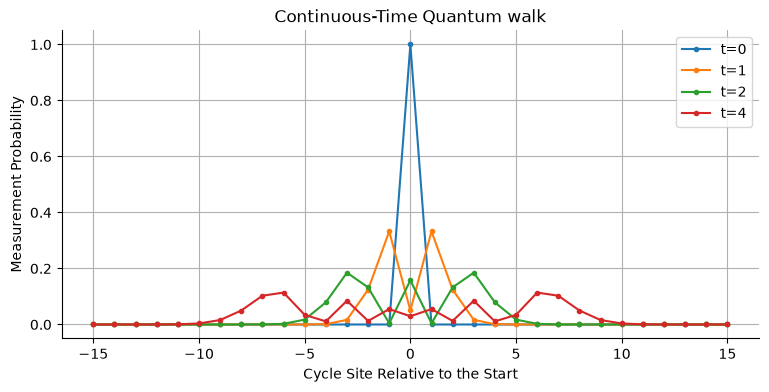

In [20]:
from scipy.linalg import expm

walk_N = 31                    # Try 21 or 41; keep it odd
gamma = 1.0
times = (0, 1, 2, 4)
assert walk_N >= 3 and walk_N % 2 == 1

H_walk = np.zeros((walk_N, walk_N), dtype=complex)
for i in range(walk_N):
    H_walk[i, (i + 1) % walk_N] = -gamma
    H_walk[i, (i - 1) % walk_N] = -gamma

psi0 = np.zeros(walk_N, dtype=complex)
psi0[walk_N // 2] = 1
positions = np.arange(walk_N) - walk_N // 2

fig, ax = plt.subplots(figsize=(9, 4))
for t in times:
    psi_t = expm(-1j * H_walk * t) @ psi0
    probability_t = np.abs(psi_t) ** 2
    assert np.isclose(probability_t.sum(), 1.0)
    ax.plot(positions, probability_t, "o-", markersize=3, label=f"t={t}")
ax.set(xlabel="Cycle Site Relative to the Start", ylabel="Measurement Probability",
       title="Continuous-Time Quantum walk")
ax.legend()
plt.show()

What should transfer from this section into Grover's algorithm is not “the particle checks every answer.” It is this more precise idea:

> Quantum operations manipulate amplitudes, including their signs and phases, so that unwanted alternatives interfere destructively and wanted alternatives interfere constructively.

Grover's algorithm engineers that process with reflections rather than with the cycle Hamiltonian above.

# 4. Overview of Grover's Algorithm

Suppose $N=2^n$ candidate bitstrings exist and, initially, exactly one target $\omega$ satisfies $f(\omega)=1$.

One Grover iteration has two operations:

1. The **phase oracle** reflects the marked component by changing its sign
2. The **diffusion operator** reflects the full state about the uniform state

The algorithm is

$$|0^n\rangle\xrightarrow{H^{\otimes n}}|s\rangle
\xrightarrow{\text{repeat }k\text{ times }(D O_f)}|\psi_k\rangle
\xrightarrow{\text{measure}}x.$$

We will pause after every transformation so the changing amplitudes remain visible.

## 4.1 Probability Initialization

Initialization assigns equal amplitude to every candidate. We will use three qubits ($N=8$) and mark $|111\rangle$. Red identifies the target for us as readers; the initial state itself does not yet favor it.

**Stop and Think:** Before the oracle runs, what is the chance of measuring $|111\rangle$?

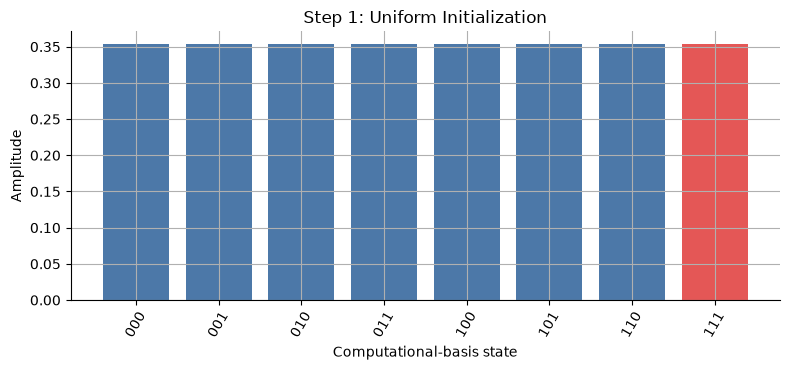

Target probability = 1/N = 0.125


In [21]:
n = 3
marked = (7,)                  # 7 is the bitstring 111; try (5,) later
N = 2 ** n
assert marked and len(set(marked)) == len(marked)
assert all(0 <= x < N for x in marked)

initial = uniform_state(n)
plot_bars(initial.real, n, "Step 1: Uniform Initialization", "Amplitude", marked)
print(f"Target probability = 1/N = {1/N:.3f}")

## 4.2 Search Operator

The oracle must be unitary, so it cannot simply announce the hidden answer or delete other states. Instead it encodes the Boolean verifier into phase:

$$O_f|x\rangle=(-1)^{f(x)}|x\rangle.$$

For one marked state, $O_f=I-2|\omega\rangle\langle\omega|$.

The Qiskit functions in `lookup.py`, `iterations.py`, and `groverPIN.py` realize this with X gates around a multi-controlled phase flip. At the amplitude level, we can express the same ideal transformation directly.

**Stop and Think:** Immediately after the sign flip, has the target become more likely to measure?

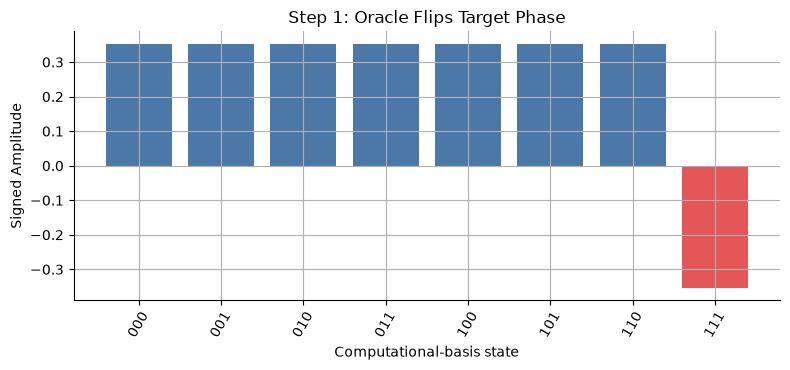

Before oracle: 0.125
After oracle:  0.125
The probability is unchanged: True


In [22]:
def phase_oracle(amplitudes, marked_states):
    '''Flip the sign of every marked computational-basis amplitude.'''
    result = amplitudes.copy()
    for index in marked_states:
        if not 0 <= index < len(result):
            raise ValueError("marked index is outside the search space")
        result[index] *= -1
    return result

after_oracle = phase_oracle(initial, marked)
plot_bars(after_oracle.real, n, "Step 1: Oracle Flips Target Phase",
          "Signed Amplitude", marked)

before_probability = sum(abs(initial[x])**2 for x in marked)
after_probability = sum(abs(after_oracle[x])**2 for x in marked)
print(f"Before oracle: {before_probability:.3f}")
print(f"After oracle:  {after_probability:.3f}")
print("The probability is unchanged:", np.isclose(before_probability, after_probability))

The answer is **no**. A phase oracle marks the target in a way that is invisible to an immediate computational-basis measurement. Its value appears only when the marked amplitude interferes with the others.

Qiskit's bit ordering deserves one practical note. The uploaded circuit code reverses target strings while deciding which qubits receive X gates because qubit 0 is the least-significant bit in the displayed integer convention. Our NumPy array uses integer index $x$ directly, so index 5 is displayed as `101` without an extra reversal in these helper functions.

## 4.3 Diffusion Operator: Inversion About the Mean

The diffusion operator is

$$D=2|s\rangle\langle s|-I.$$

Because $|s\rangle$ points along the uniform-amplitude direction, $D$ reflects the state about that direction. For the real amplitudes in this example,

$$a_x' = 2\bar a-a_x,$$

where $\bar a$ is the mean amplitude immediately before diffusion. After the oracle, the target is below the mean. Reflecting it across the mean sends it above the mean, while the unmarked amplitudes decrease.

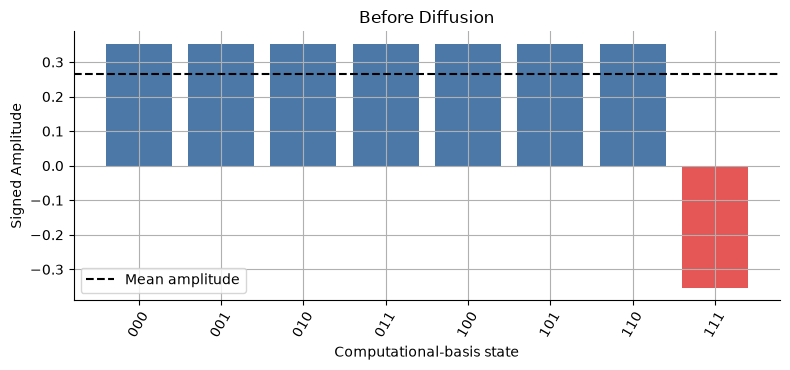

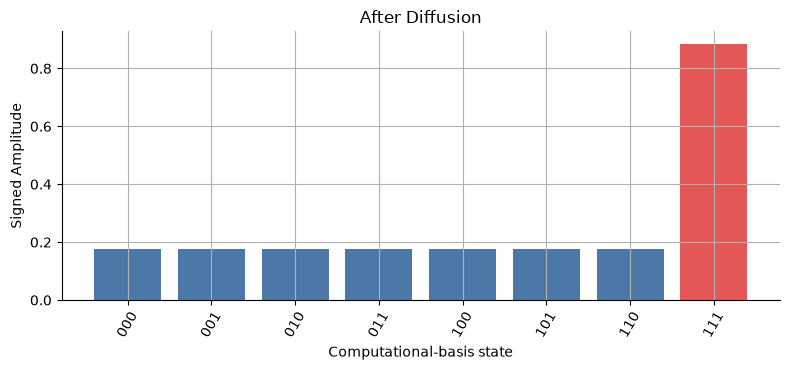

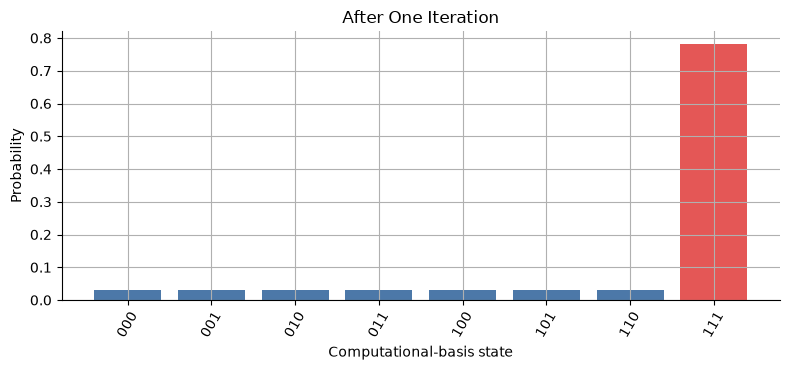

Mean Amplitude before diffusion: 0.2652
Success probability after one iteration: 0.7812
Normalization preserved: True


In [23]:
def diffuse(amplitudes):
    '''Apply D = 2|s><s| - I in the full computational basis.'''
    return 2 * np.mean(amplitudes) - amplitudes

def grover_step(amplitudes, marked_states):
    '''One complete Grover iteration: oracle, then diffusion.'''
    return diffuse(phase_oracle(amplitudes, marked_states))

mean_after_oracle = np.mean(after_oracle.real)
after_diffusion = diffuse(after_oracle)

plot_bars(after_oracle.real, n, "Before Diffusion",
          "Signed Amplitude", marked, mean_line=True)
plot_bars(after_diffusion.real, n, "After Diffusion",
          "Signed Amplitude", marked)
plot_bars(abs(after_diffusion)**2, n, "After One Iteration",
          "Probability", marked)

success_after_one = sum(abs(after_diffusion[x])**2 for x in marked)
print(f"Mean Amplitude before diffusion: {mean_after_oracle:.4f}")
print(f"Success probability after one iteration: {success_after_one:.4f}")
print("Normalization preserved:", np.isclose(np.vdot(after_diffusion, after_diffusion).real, 1))

### 4.4 Follow Every Amplitude Numerically

For $N=8$, the uniform amplitude is about $0.3536$. The table makes the two-reflection process explicit. This numerical trace is the shortest complete explanation of one Grover iteration.

In [24]:
print("State | Initialized | After Oracle | After Diffusion | Final Probability")
print("------|-------------|--------------|-----------------|------------------")
for x in range(N):
    print(f"{bit_label(x, n):>5} | {initial[x].real:11.4f} |"
          f" {after_oracle[x].real:12.4f} | {after_diffusion[x].real:15.4f} |"
          f" {abs(after_diffusion[x])**2:16.4f}")

State | Initialized | After Oracle | After Diffusion | Final Probability
------|-------------|--------------|-----------------|------------------
  000 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  001 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  010 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  011 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  100 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  101 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  110 |      0.3536 |       0.3536 |          0.1768 |           0.0312
  111 |      0.3536 |      -0.3536 |          0.8839 |           0.7812


**Checkpoint 2**

1. Which operation first distinguishes the target from the other candidates?
2. Why can that distinction not be seen in the probability bars immediately?
3. Which operation converts the phase distinction into greater target probability?

<details><summary>Check your reasoning</summary>

1. The oracle changes the target's phase.
2. Negating an amplitude does not change its squared magnitude.
3. Diffusion creates interference by reflecting all amplitudes about their mean.

</details>

# 5. Grover's Circle and Time Complexity

One iteration often improves the target probability, but not always enough. Repeating forever also fails, however, as Grover's operation is analagous to rotation between target and non-target basis vectors. It eventually passes the target direction and moves away again.

Although the full statevector has $N$ components, the ideal search stays inside a two-dimensional subspace. For one target, define

$$|\omega^\perp\rangle=\frac{1}{\sqrt{N-1}}\sum_{x\ne\omega}|x\rangle.$$

The uniform state decomposes as

$$|s\rangle=\sin\theta|\omega\rangle+\cos\theta|\omega^\perp\rangle,
\qquad \sin\theta=\frac{1}{\sqrt N}.$$

The oracle reflects across the $|\omega^\perp\rangle$ axis. Diffusion reflects across $|s\rangle$. Two reflections compose into a rotation by $2\theta$.

### 5.1 Watch the State Rotate

After $k$ full Grover iterations,

$$|\psi_k\rangle=\sin((2k+1)\theta)|\omega\rangle
+\cos((2k+1)\theta)|\omega^\perp\rangle.$$

The vertical coordinate below is the target amplitude. The target probability is its square. The state remains on the unit circle because every operation is unitary.

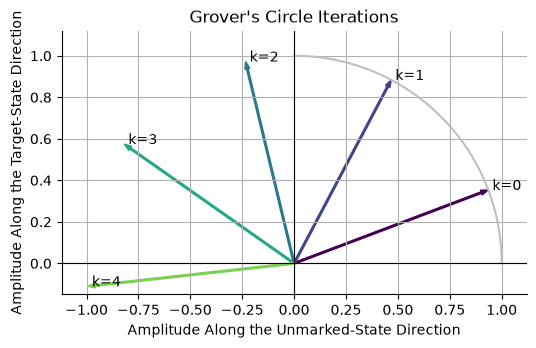

In [25]:
theta = math.asin(1 / math.sqrt(N))
angles = (2 * np.arange(5) + 1) * theta

fig, ax = plt.subplots(figsize=(6, 6))
circle_angle = np.linspace(0, np.pi/2, 300)
ax.plot(np.cos(circle_angle), np.sin(circle_angle), color="0.75")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
for k, angle in enumerate(angles):
    x_coord, y_coord = np.cos(angle), np.sin(angle)
    ax.arrow(0, 0, x_coord, y_coord, width=0.008,
             length_includes_head=True, color=plt.cm.viridis(k / 5))
    ax.text(x_coord + 0.02, y_coord, f"k={k}")
ax.set(xlim=(-1.12, 1.12), ylim=(-0.15, 1.12), aspect="equal",
       xlabel="Amplitude Along the Unmarked-State Direction",
       ylabel="Amplitude Along the Target-State Direction",
       title="Grover's Circle Iterations")
plt.show()

### 5.2 Deriving the Stopping Point

We want $(2k+1)\theta$ as close as possible to $\pi/2$, because that direction is the target state $|\omega\rangle$. Solving the ideal equality gives

$$k=\frac{\pi}{4\theta}-\frac12.$$

For one target, $\theta=\arcsin(1/\sqrt N)$. When $N$ is large, $\arcsin(1/\sqrt N)\approx1/\sqrt N$, so

$$k\approx\frac\pi4\sqrt N-\frac12.$$

Because a circuit uses an integer number of iterations, we choose a nearby integer and may compare neighboring choices. The exact target probability is

$$P_k=\sin^2((2k+1)\theta).$$

In [26]:
def recommended_iterations(N, M=1):
    '''A near-optimal integer iteration count when M is known.'''
    if not 1 <= M <= N:
        raise ValueError("Expected 1 <= M <= N")
    if M == N:
        return 0
    theta = math.asin(math.sqrt(M / N))
    return max(0, round(math.pi / (4 * theta) - 0.5))

def success_probability_theory(N, M, k):
    theta = math.asin(math.sqrt(M / N))
    return math.sin((2*k + 1) * theta) ** 2

print("  N | Suggested k | Success Probability")
print("----|-------------|--------------------")
for candidate_count in (4, 8, 16, 64, 256, 1024):
    k = recommended_iterations(candidate_count)
    p = success_probability_theory(candidate_count, 1, k)
    print(f"{candidate_count:3d} | {k:11d} | {p:19.6f}")

  N | Suggested k | Success Probability
----|-------------|--------------------
  4 |           1 |            1.000000
  8 |           2 |            0.945312
 16 |           3 |            0.961319
 64 |           6 |            0.996586
256 |          12 |            0.999947
1024 |          25 |            0.999461


### 5.3 Amplification and Overshooting

The probability oscillates; it does not rise monotonically. The experiment compares the exact formula with a statevector simulation.

**Try It:** Change `marked_curve` from `(7,)` to `(2, 5)`. The initial success probability rises because there are two solutions, and the best iteration count falls. If you want to run the program for a different single state target, make sure to keep the comma within the parentheses (i.e. `(#,)`).

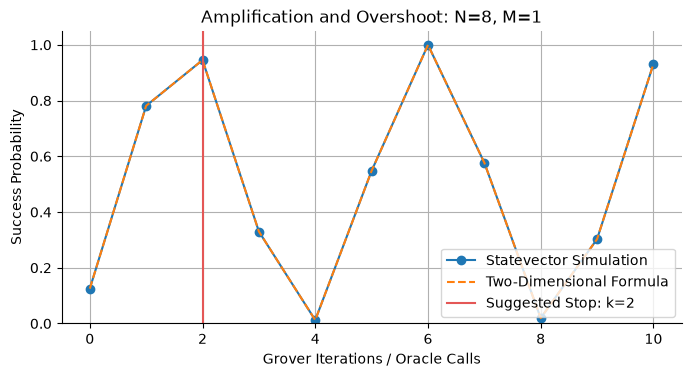

In [34]:
def probability_curve(n, marked_states, max_k):
    amplitudes = uniform_state(n)
    curve = []
    for _k in range(max_k + 1):
        curve.append(sum(abs(amplitudes[x])**2 for x in marked_states))
        amplitudes = grover_step(amplitudes, marked_states)
    return np.array(curve)

n_curve = 3
marked_curve = (7,)             # Try (2, 5)
N_curve = 2 ** n_curve
M_curve = len(marked_curve)
k_stop = recommended_iterations(N_curve, M_curve)
k_values = np.arange(11)

simulated = probability_curve(n_curve, marked_curve, int(k_values[-1]))
theta_curve = math.asin(math.sqrt(M_curve / N_curve))
predicted = np.sin((2*k_values + 1) * theta_curve) ** 2
assert np.allclose(simulated, predicted)

fig, ax = plt.subplots()
ax.plot(k_values, simulated, "o-", label="Statevector Simulation")
ax.plot(k_values, predicted, "--", label="Two-Dimensional Formula")
ax.axvline(k_stop, color=RED, label=f"Suggested Stop: k={k_stop}")
ax.set(xlabel="Grover Iterations / Oracle Calls", ylabel="Success Probability",
       ylim=(0, 1.05), title=f"Amplification and Overshoot: N={N_curve}, M={M_curve}")
ax.legend()
plt.show()

### 5.4 More Than One Marked State

If $M$ states are marked, replace $1/\sqrt N$ with $\sqrt{M/N}$:

$$\sin\theta=\sqrt{\frac MN},\qquad k=\Theta\!\left(\sqrt{\frac NM}\right).$$

The algorithm amplifies the **marked subspace**. In the symmetric setup, measurement distributes the total marked probability equally across marked states. The one-target formula should not be used unchanged when $M>1$.

If $M$ is unknown, blindly using the one-target count can overshoot. Practical variants use randomized or adaptive iteration schedules.

# 6. Simulation and Linear-Search Comparison

We can now assemble a complete ideal search:

1. Initialize the uniform state
2. Repeat oracle and diffusion near the recommended number of times
3. Measure the final state
4. Verify the measured candidate classically

`lookup.py` builds and samples one Qiskit circuit. `iterations.py` calculates success probability across iteration counts. The next experiment combines those perspectives while exposing the full statevector.

### 6.1 Exact Probabilities Versus Finite Measurements

An ideal statevector gives exact probabilities. A real experiment estimates those probabilities with repeated circuit executions, called **shots**. The observed histogram fluctuates.

**Try It:** Change `shots` from 1,000 to 50 and rerun. Then change it to 10,000. The exact distribution stays fixed while the sampled histogram stabilizes.

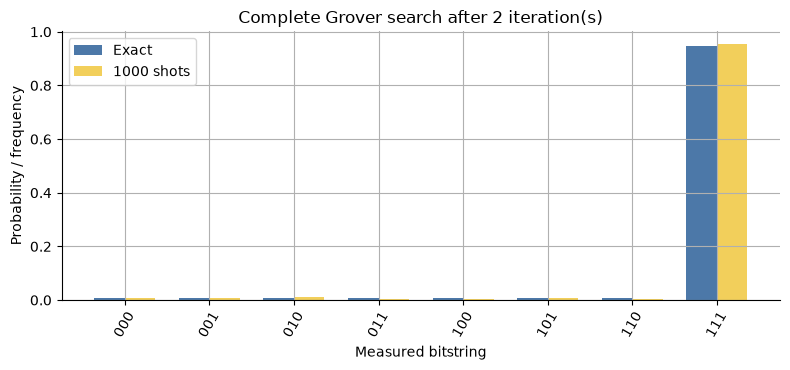

Marked states: ['111']
Exact marked probability: 0.9453
Observed marked frequency: 0.9540


In [28]:
n_demo = 3
marked_demo = (7,)              # Try (5,) or (1, 6)
shots = 1000
assert marked_demo and len(marked_demo) == len(set(marked_demo))
assert all(0 <= x < 2**n_demo for x in marked_demo)

k_demo = recommended_iterations(2**n_demo, len(marked_demo))
final_state = uniform_state(n_demo)
for _ in range(k_demo):
    final_state = grover_step(final_state, marked_demo)

exact = abs(final_state) ** 2
rng = np.random.default_rng(2025)
samples = rng.choice(2**n_demo, size=shots, p=exact)
sampled = np.bincount(samples, minlength=2**n_demo) / shots

x = np.arange(2**n_demo)
fig, ax = plt.subplots()
ax.bar(x - 0.18, exact, width=0.36, color=BLUE, label="Exact")
ax.bar(x + 0.18, sampled, width=0.36, color=GOLD, label=f"{shots} shots")
ax.set_xticks(x, [bit_label(i, n_demo) for i in x], rotation=60)
ax.set(xlabel="Measured bitstring", ylabel="Probability / frequency",
       title=f"Complete Grover search after {k_demo} iteration(s)")
ax.legend()
plt.tight_layout()
plt.show()

print("Marked states:", [bit_label(x, n_demo) for x in marked_demo])
print(f"Exact marked probability: {sum(exact[x] for x in marked_demo):.4f}")
print(f"Observed marked frequency: {sum(sampled[x] for x in marked_demo):.4f}")

### 6.2 What the Complexity Comparison Measures

Linear search takes $\Theta(N)$ verifier calls in the worst case. Grover's algorithm takes $\Theta(\sqrt{N/M})$ **quantum oracle calls** when $M$ is known and small. This is a quadratic query advantage, not an exponential one.

The plot compares idealized query counts. A quantum iteration contains both an oracle circuit and diffusion; building those circuits, loading data, correcting errors, and running hardware all cost time.

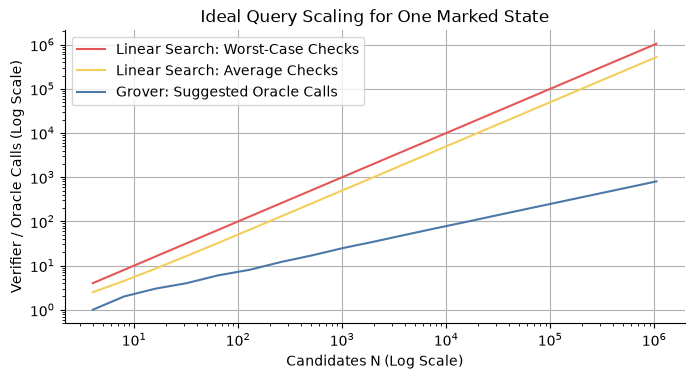

In [35]:
qubit_counts = np.arange(2, 21)
search_sizes = 2 ** qubit_counts
classical_average = (search_sizes + 1) / 2
classical_worst = search_sizes
grover_queries = np.array([recommended_iterations(int(size)) for size in search_sizes])

fig, ax = plt.subplots()
ax.loglog(search_sizes, classical_worst, label="Linear Search: Worst-Case Checks", color=RED)
ax.loglog(search_sizes, classical_average, label="Linear Search: Average Checks", color=GOLD)
ax.loglog(search_sizes, grover_queries, label="Grover: Suggested Oracle Calls", color=BLUE)
ax.set(xlabel="Candidates N (Log Scale)", ylabel="Verifier / Oracle Calls (Log Scale)",
       title="Ideal Query Scaling for One Marked State")
ax.legend()
plt.show()

### 6.3 Toy PIN Recovery

`groverPIN.py` treats a four-digit PIN as a candidate integer and creates a phase oracle that marks the chosen value. This is a safe classroom model of a verifier, not a tool for accessing a real system.

A four-digit PIN has 10,000 valid values, but a qubit register has a power-of-two dimension. Fourteen qubits provide $2^{14}=16{,}384$ basis states. The uploaded circuit marks one state in this full register and filters invalid labels only when plotting. Therefore its correct rotation angle and iteration count use $N=16{,}384$, not $N=10{,}000$.

Filtering a histogram after measurement does not change the state that evolved before measurement.

Secret label: 0420
14-bit basis state: |00000110100100>
Register dimension: 16,384
Valid four-digit labels: 10,000
Suggested iterations for this circuit: 100
Ideal success probability: 1.000000


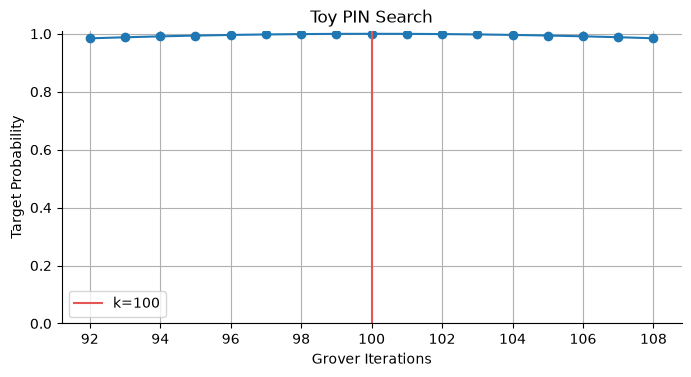

In [37]:
pin = "0420"                    # Try another four-digit string
assert len(pin) == 4 and pin.isdigit()

secret = int(pin)
pin_n = math.ceil(math.log2(10000))
pin_N = 2 ** pin_n
pin_k = recommended_iterations(pin_N)
pin_theta = math.asin(1 / math.sqrt(pin_N))
pin_success = math.sin((2*pin_k + 1) * pin_theta) ** 2

print(f"Secret label: {pin}")
print(f"14-bit basis state: |{secret:014b}>")
print(f"Register dimension: {pin_N:,}")
print("Valid four-digit labels: 10,000")
print(f"Suggested iterations for this circuit: {pin_k}")
print(f"Ideal success probability: {pin_success:.6f}")

local_k = np.arange(pin_k - 8, pin_k + 9)
local_probability = np.sin((2*local_k + 1) * pin_theta) ** 2
fig, ax = plt.subplots()
ax.plot(local_k, local_probability, "o-")
ax.axvline(pin_k, color=RED, label=f"k={pin_k}")
ax.set(xlabel="Grover Iterations", ylabel="Target Probability", ylim=(0, 1.01),
       title="Toy PIN Search")
ax.legend()
plt.show()

The next cell runs the full 16,384-amplitude simulation and samples it. Because the ideal probability near the peak is extremely close to one, nearly every shot should return the secret. Invalid basis states still exist even if they rarely appear at this stopping point.

In [31]:
pin_state = uniform_state(pin_n)
for _ in range(pin_k):
    pin_state = grover_step(pin_state, (secret,))

pin_probabilities = abs(pin_state) ** 2
pin_shots = 2000
pin_rng = np.random.default_rng(420)
pin_samples = pin_rng.choice(pin_N, size=pin_shots, p=pin_probabilities)

secret_hits = np.count_nonzero(pin_samples == secret)
invalid_hits = np.count_nonzero(pin_samples >= 10000)
print(f"Secret hits: {secret_hits}/{pin_shots}")
print(f"Invalid-label hits: {invalid_hits}/{pin_shots}")
print(f"Exact secret probability: {pin_probabilities[secret]:.6f}")

Secret hits: 2000/2000
Invalid-label hits: 0/2000
Exact secret probability: 1.000000


### 6.4 Mapping the Uploaded Scripts to the Lesson

| Project file | Role in the project | Notebook counterpart |
|---|---|---|
| `linearSearch.py` | Animated sequential search | Section 1.1 and query comparison |
| `quantumRandomWalk.py` | Continuous-time walk on a cycle | Section 3 |
| `groverSearch.py` | Oracle for marked bitstrings and IBM hardware selection | Sections 4.2–4.3 at the amplitude level |
| `lookup.py` | Builds and samples a small Grover circuit | Section 6.1 |
| `iterations.py` | Plots target probability versus iteration | Section 5.3 |
| `groverPIN.py` | Demonstrates a 14-qubit toy PIN verifier | Section 6.3 |

The notebook intentionally does not connect to IBM hardware. A teaching notebook should run without credentials, queue access, or device noise. The Qiskit scripts remain useful for translating the mathematical operations into gates.

# 7. Applications

Grover's algorithm applies when candidates can be placed in coherent superposition and a reversible quantum oracle can recognize solutions. It's predicated upon the ability to implement a sufficiently cheap reversible predicate $f(x)$ whose input you want to find. 

| Area | Candidate $x$ | What the Oracle Must Verify | Important Caveat |
|---|---|---|---|
| Log anomaly search | Log-entry index | Entry satisfies a precise anomaly rule | Loading logs and defining a reversible rule may dominate |
| Symmetric-key search | Candidate key | Encryption/decryption matches known data | Grover only quadratically reduces brute force |
| Discrete pattern matching | Candidate location/configuration | Pattern matches exactly | Data access and reversible comparison cost matter |
| Hyperparameter search | Discrete configuration | Configuration meets a threshold | Model evaluation may be far more expensive than diffusion |
| General black-box search | Candidate input | Boolean predicate is true | The oracle is an assumption that must be implemented |

Note: in cryptography, searching an $n$-bit key space changes ideal query scaling from roughly $2^n$ to $2^{n/2}$. That is consequential, but it does not make the search polynomial in $n$. The computational cost of your developed oracle should always be a factor taken into consideration.

### 7.1 A Toy Predicate, Separated From the Search Machinery

The code below demonstrates the abstraction. The predicate first determines which indices count as solutions. The amplitude simulation then receives those marked indices. A gate-level quantum program would have to implement the predicate reversibly rather than calculate the answers classically in advance.

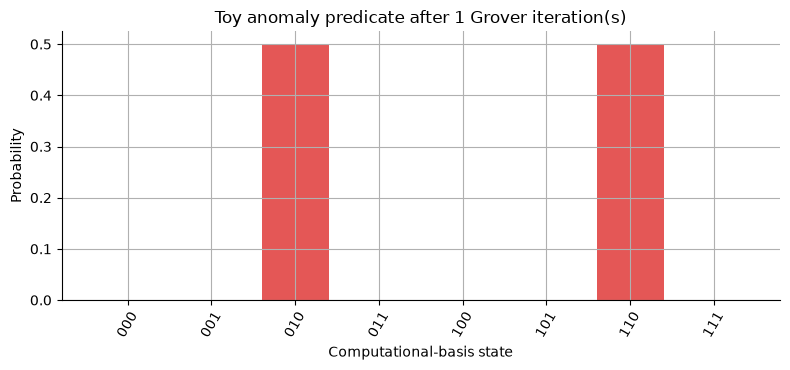

Marked record indices: (2, 6)


In [36]:
def toy_anomaly_rule(record):
    '''A deliberately simple classical rule for a teaching example.'''
    return record["failed_logins"] >= 5 and record["country_changed"]

records = [
    {"failed_logins": 0, "country_changed": False},
    {"failed_logins": 2, "country_changed": True},
    {"failed_logins": 7, "country_changed": True},   # marked
    {"failed_logins": 1, "country_changed": False},
    {"failed_logins": 6, "country_changed": False},
    {"failed_logins": 3, "country_changed": True},
    {"failed_logins": 8, "country_changed": True},   # marked
    {"failed_logins": 0, "country_changed": True},
]

anomalies = tuple(i for i, record in enumerate(records) if toy_anomaly_rule(record))
anomaly_n = 3
anomaly_k = recommended_iterations(2**anomaly_n, len(anomalies))
anomaly_state = uniform_state(anomaly_n)
for _ in range(anomaly_k):
    anomaly_state = grover_step(anomaly_state, anomalies)

plot_bars(abs(anomaly_state)**2, anomaly_n,
          f"Toy anomaly predicate after {anomaly_k} Grover iteration(s)", marked=anomalies)
print("Marked record indices:", anomalies)

# 8. Limitations

Grover's algorithm is mathematically powerful, but several qualifications prevent the ideal query curve from becoming an automatic real-world speedup.

1. **The oracle is not free**: The complexity statement counts oracle calls. A real oracle must be a reversible circuit. If recognizing a solution requires a large classical computation, complicated data loading, or many ancillary qubits, that work remains.

2. **State preparation and data access matter**: Searching values stored in an ordinary classical database may require coherent data access. The cost of preparing or accessing the data cannot simply be ignored.

3. **The number of solutions may be unknown**: The best iteration count depends on $M$. Running too long causes overshoot. Unknown-$M$ search requires an adaptive or randomized variant.

4. **Hardware is noisy**: Multi-controlled operations, oracle logic, and diffusion must be decomposed into hardware-native gates. Realistically, circuit depth, decoherence, gate errors, connectivity, and error-correction overhead constrain useful sizes. The cushioning of quantum information remains the central dilemma of quantum computing.

5. **The advantage is quadratic and problem-specific**: Grover changes $\Theta(N)$ oracle queries into $\Theta(\sqrt N)$ for one solution. It is not an exponential speedup, and structured problems may have better classical algorithms than linear search.

**Final Conceptual Check**

Decide whether each statement is true or false before opening the answer.

1. The oracle makes the target more probable immediately after it runs.
2. One Grover iteration consists of an oracle followed by diffusion.
3. More iterations always improve the probability of measuring a solution.
4. Grover's $O(\sqrt N)$ describes ideal oracle-query scaling.
5. A 14-qubit register contains exactly 10,000 basis states.

<details><summary>Answers</summary>

1. **False.** It flips phase; the probability is initially unchanged.
2. **True.** In this convention, $G=DO_f$.
3. **False.** The state rotates past the target and success probability oscillates.
4. **True.** It does not, by itself, include all circuit, data, and hardware costs.
5. **False.** It contains $2^{14}=16{,}384$ states; only 10,000 are valid four-digit PIN labels.

</details>

# 9. Conclusion

Grover's algorithm begins with ignorance. Every candidate has the same amplitude. The oracle does not reveal the answer and it gives solution states a relative phase. Diffusion then uses interference to convert that phase difference into greater solution amplitude. Repeating the two reflections rotates the state toward the marked subspace, and measurement is performed near the first probability peak.

That mechanism produces a quadratic reduction in ideal oracle queries for unstructured search. The result is more precise and more interesting than saying that a quantum computer “checks every answer at once.” The computation succeeds because amplitudes carry signs and phases, and because the circuit is designed so those amplitudes interfere in a useful direction.

## Further Experiments

1. Change the marked state in Section 4 and verify that every bitstring is treated symmetrically.
2. Mark two states in Section 5.3 and explain why the iteration count changes.
3. Change the shot count in Section 6.1 and quantify the sampling error.
4. Compare the $N=10{,}000$ and $N=16{,}384$ theoretical PIN curves.
5. Extend `phase_oracle` to accept a Boolean predicate over integer indices.
6. Translate the $N=8$ NumPy example back into the gate-level Qiskit construction in `lookup.py`.

## Selected References

- L. K. Grover, “A fast quantum mechanical algorithm for database search,” *Proceedings of STOC*, 1996.
- M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, Cambridge University Press, 2010.
- IBM Quantum Learning, “Grover's algorithm.”
- C. H. Bennett, E. Bernstein, G. Brassard, and U. Vazirani, “Strengths and weaknesses of quantum computing,” *SIAM Journal on Computing*, 1997.